# **1. Perkenalan Dataset**
Proyek ini bertujuan untuk membangun sistem Machine Learning yang mampu memprediksi harga sewa kost promo di platform Mamikos. Prediksi didasarkan pada berbagai fitur penting seperti kota, gender target kost, rating, kecamatan (district), dan fasilitas yang disediakan.

Analisis ini akan dilakukan secara eksploratif dan bertahap (naratif) di mana setiap penemuan di satu langkah akan memandu keputusan di langkah berikutnya.

# **2. Import Library**
Kita akan menggunakan library standar analisis data Python, termasuk library visualisasi `matplotlib` dan `seaborn` untuk menganalisis hubungan antar variabel secara visual.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Mengatur style visualisasi agar terlihat premium dan modern
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# **3. Memuat Dataset**
Mari kita muat file dataset mentah hasil scraping untuk melihat struktur data awal.

In [2]:
df = pd.read_csv("mamikos_promo_ngebut_indonesia.csv")
print("Dataset Shape:", df.shape)
print("\nLima baris pertama dataset:")
print(df.head(5))

Dataset Shape: (2061, 9)

Lima baris pertama dataset:
      city                                   title  gender  rating  \
0  Bandung                Kost Dago Pakar 4 Tipe A   Putra     4.9   
1  Bandung  Kost Griya Nararya I Dago Barat Tipe A   Putra     4.9   
2  Bandung        Kost Pondok Natasha UNPAD Tipe A  Campur     4.8   
3  Bandung                Kost Ernawati BSC Tipe B  Campur     NaN   
4  Bandung                Kost Ernawati BSC Tipe A  Campur     NaN   

           district                                 facilities original_price  \
0  Cibeunying Kaler       WiFi·Kloset Duduk·Kasur·Akses 24 Jam    Rp1.285.000   
1           Coblong  K. Mandi Dalam·WiFi·AC·Kloset Duduk·Kasur    Rp2.140.000   
2        Jatinangor     K. Mandi Dalam·WiFi·Kasur·Akses 24 Jam      Rp835.000   
3           Coblong     K. Mandi Dalam·WiFi·Kloset Duduk·Kasur    Rp1.564.000   
4           Coblong     K. Mandi Dalam·WiFi·Kloset Duduk·Kasur    Rp1.897.000   

  discount_price                      

# **4. Exploratory Data Analysis (EDA) & Investigasi Data**

## **Langkah 4.1: Informasi Awal & Deteksi Missing Values**
Pertama, kita periksa tipe data dan keberadaan nilai yang kosong (*missing values*) pada masing-masing kolom.

In [3]:
print(df.info())
print("\nJumlah missing values per kolom:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2061 entries, 0 to 2060
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            2061 non-null   object 
 1   title           2061 non-null   object 
 2   gender          2061 non-null   object 
 3   rating          1859 non-null   float64
 4   district        2061 non-null   object 
 5   facilities      2061 non-null   object 
 6   original_price  2045 non-null   object 
 7   discount_price  2061 non-null   object 
 8   full_card_text  2061 non-null   object 
dtypes: float64(1), object(8)
memory usage: 145.0+ KB
None

Jumlah missing values per kolom:
city                0
title               0
gender              0
rating            202
district            0
facilities          0
original_price     16
discount_price      0
full_card_text      0
dtype: int64


**Temuan & Hipotesis Awal:**
1. Kolom `original_price` and `discount_price` bertipe `object` (string) karena format teks rupiah (misal: "Rp1.285.000"). Kita harus mengubahnya menjadi tipe data numerik agar bisa dilakukan analisis kuantitatif.
2. Terdapat **202 missing values** pada kolom `rating` dan **16 missing values** pada `original_price`. Kita perlu menyelidiki karakteristik data kosong ini dan menentukan strategi imputasi yang tepat.

---

## **Langkah 4.2: Pembersihan & Parsing Kolom Harga**
Kita buat fungsi pembantu untuk membersihkan string harga dari simbol `Rp`, titik ribuan, dan suffix (seperti `/bulan` atau `/hari`) agar menjadi format angka mengambang (`float`).

In [4]:
def parse_price(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace('Rp', '').replace('.', '').strip()
    if '/' in val_str:
        val_str = val_str.split('/')[0].strip()
    try:
        return float(val_str)
    except ValueError:
        return np.nan

df['clean_original_price'] = df['original_price'].apply(parse_price)
df['clean_discount_price'] = df['discount_price'].apply(parse_price)

print("Statistik Deskriptif Kolom Harga:")
print(df[['clean_original_price', 'clean_discount_price']].describe())

Statistik Deskriptif Kolom Harga:
       clean_original_price  clean_discount_price
count          2.045000e+03          2.061000e+03
mean           1.655758e+06          1.547119e+06
std            6.509328e+05          6.252986e+05
min            4.950000e+05          4.356000e+05
25%            1.225000e+06          1.150000e+06
50%            1.575000e+06          1.456000e+06
75%            2.000000e+06          1.865000e+06
max            5.375000e+06          5.054000e+06


**Temuan:**
- Harga diskon rata-rata kost adalah Rp1,54 juta, dengan rentang harga dari Rp435 ribu hingga Rp5,05 juta.
- Sekarang setelah harga bertipe numerik, kita dapat melihat distribusi variabel target (`clean_discount_price`) dan hubungannya dengan harga asli.

---

## **Langkah 4.3: Visualisasi Distribusi Target & Hubungan Harga Asli vs Diskon**
Mari kita buat plot untuk memahami distribusi harga diskon dan melihat korelasi linier antara harga asli dan harga diskon.

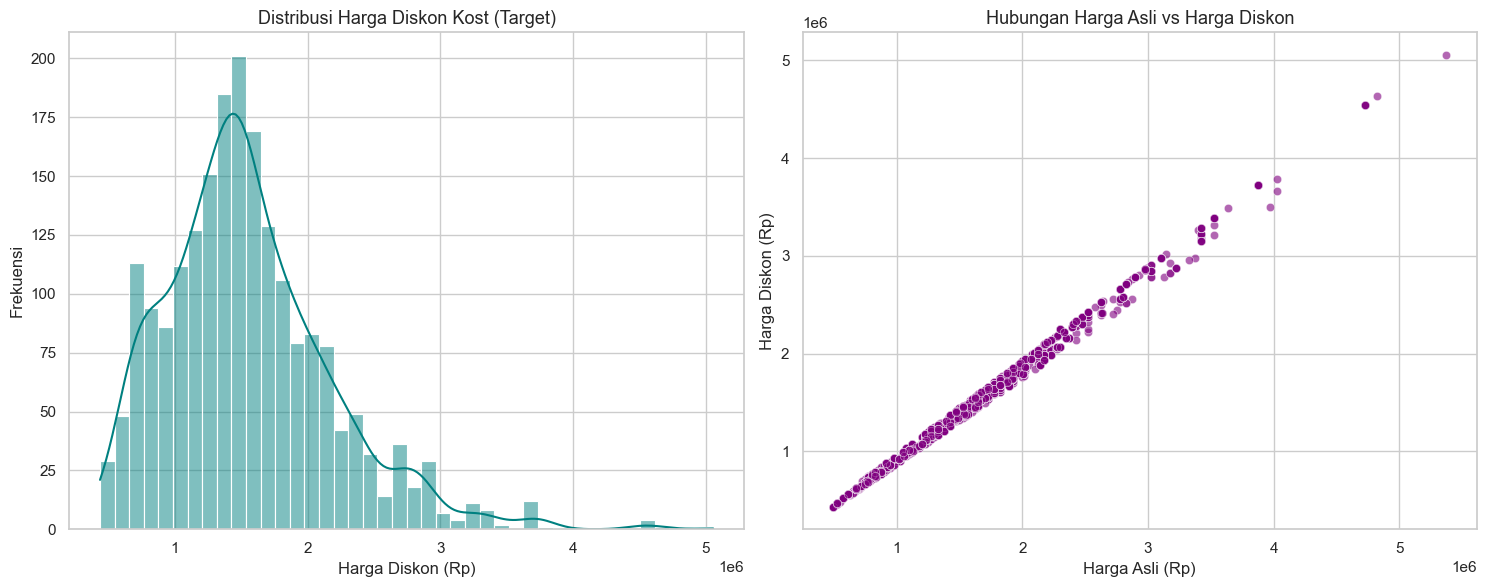

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Distribusi Harga Diskon (Target)
sns.histplot(df['clean_discount_price'], kde=True, color='teal', ax=axes[0])
axes[0].set_title("Distribusi Harga Diskon Kost (Target)", fontsize=13)
axes[0].set_xlabel("Harga Diskon (Rp)")
axes[0].set_ylabel("Frekuensi")

# Plot 2: Korelasi Harga Asli vs Diskon
sns.scatterplot(data=df, x='clean_original_price', y='clean_discount_price', alpha=0.6, color='purple', ax=axes[1])
axes[1].set_title("Hubungan Harga Asli vs Harga Diskon", fontsize=13)
axes[1].set_xlabel("Harga Asli (Rp)")
axes[1].set_ylabel("Harga Diskon (Rp)")

plt.tight_layout()
plt.show()

**Temuan:**
1. Distribusi harga diskon miring ke kanan (*right-skewed*). Mayoritas harga sewa kost menumpuk di kisaran Rp1.000.000 s/d Rp2.000.000. Kost premium dengan harga di atas Rp3.000.000 jumlahnya sangat sedikit.
2. Terlihat hubungan linier yang sangat kuat antara `clean_original_price` dan `clean_discount_price`. Ini menandakan diskon diberikan secara proporsional. Namun, apakah harga ini dipengaruhi oleh letak kota atau kategori gender kost?

---

## **Langkah 4.4: Pengaruh Kategorikal (Kota & Gender) Terhadap Harga**
Mari kita buat boxplot untuk menganalisis penyebaran harga diskon kost berdasarkan Kota dan Gender.

C:\Users\dzakw\AppData\Local\Temp\ipykernel_13536\2330472795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city', y='clean_discount_price', palette='Set2', ax=axes[0])


C:\Users\dzakw\AppData\Local\Temp\ipykernel_13536\2330472795.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='clean_discount_price', palette='Pastel1', ax=axes[1])


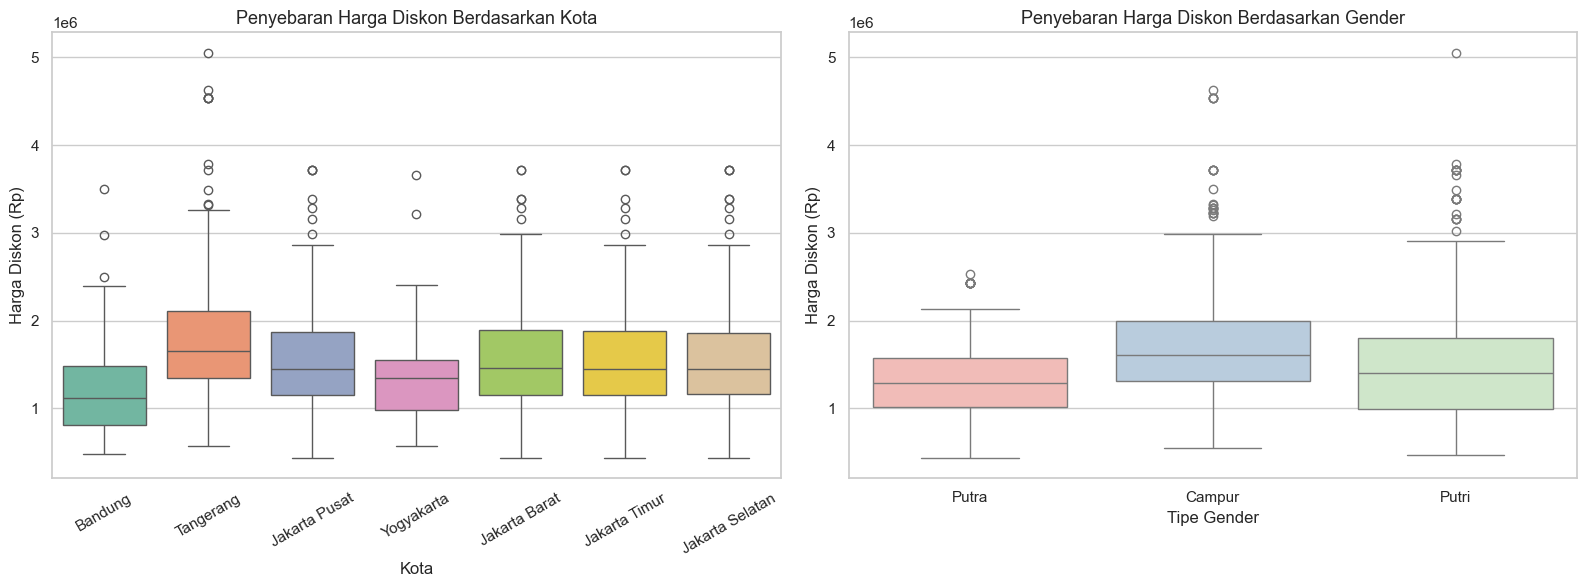

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Kota vs Harga
sns.boxplot(data=df, x='city', y='clean_discount_price', palette='Set2', ax=axes[0])
axes[0].set_title("Penyebaran Harga Diskon Berdasarkan Kota", fontsize=13)
axes[0].set_xlabel("Kota")
axes[0].set_ylabel("Harga Diskon (Rp)")
axes[0].tick_params(axis='x', rotation=30)

# Boxplot Gender vs Harga
sns.boxplot(data=df, x='gender', y='clean_discount_price', palette='Pastel1', ax=axes[1])
axes[1].set_title("Penyebaran Harga Diskon Berdasarkan Gender", fontsize=13)
axes[1].set_xlabel("Tipe Gender")
axes[1].set_ylabel("Harga Diskon (Rp)")

plt.tight_layout()
plt.show()

**Temuan:**
1. **Faktor Kota**: Kost di area Tangerang dan DKI Jakarta (Selatan, Pusat, Barat, Timur) memiliki median harga yang jauh lebih tinggi dibandingkan Yogyakarta dan Bandung. Ini menunjukkan letak kota merupakan faktor penentu utama harga kost.
2. **Faktor Gender**: Kost dengan tipe "Campur" memiliki median harga yang lebih tinggi dibandingkan kost khusus "Putra" atau "Putri".

Namun, kota masih terlalu luas. Apakah kecamatan (`district`) memiliki peran yang lebih spesifik dalam membentuk harga sewa kost?

---

## **Langkah 4.5: Analisis Lokasi Mikro (Tingkat Kecamatan/District)**
Mari kita teliti 10 kecamatan terpopuler dalam dataset dan buat visualisasi rata-rata harga sewanya untuk melihat variasi harga tingkat mikro.

C:\Users\dzakw\AppData\Local\Temp\ipykernel_13536\845552642.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


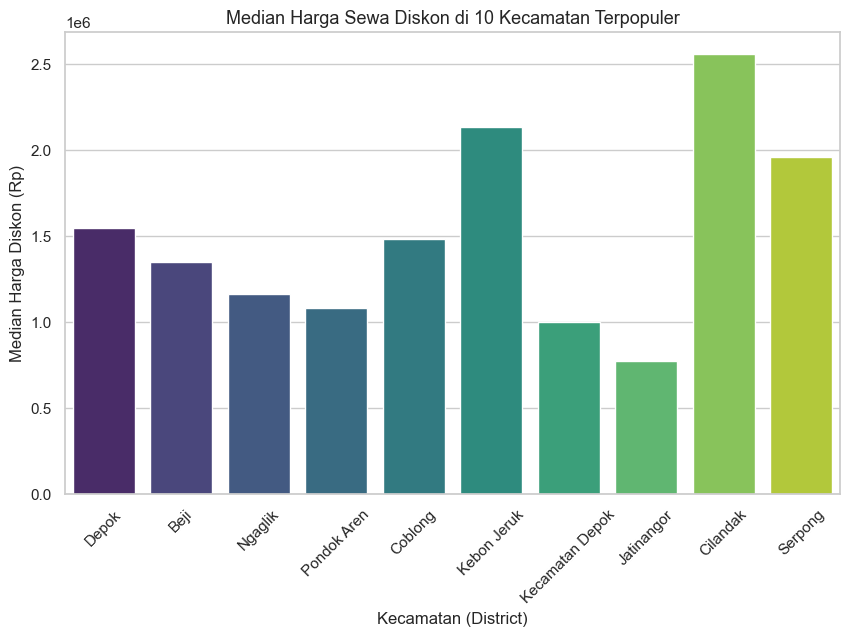

In [7]:
top_districts = df['district'].value_counts().head(10).index
df_top_dist = df[df['district'].isin(top_districts)]

sns.barplot(
    data=df_top_dist, 
    x='district', 
    y='clean_discount_price', 
    estimator=np.median, 
    errorbar=None, 
    palette='viridis',
    order=top_districts
)
plt.title("Median Harga Sewa Diskon di 10 Kecamatan Terpopuler", fontsize=13)
plt.xlabel("Kecamatan (District)")
plt.ylabel("Median Harga Diskon (Rp)")
plt.xticks(rotation=45)
plt.show()

**Temuan:**
Kecamatan seperti *Serpong* (Tangerang) dan *Cilandak* (Jakarta Selatan) memiliki median harga sewa diskon yang jauh lebih mahal (> Rp1.800.000) dibandingkan wilayah *Depok* atau *Beji* (< Rp1.200.000). Ini membuktikan bahwa fitur kecamatan (`district`) sangat sensitif terhadap harga sewa dan harus dipertahankan untuk melatih model ML.

Pertanyaan selanjutnya: Selain lokasi, fasilitas apa saja yang paling memengaruhi harga sewa kost?

---

## **Langkah 4.6: Ekstraksi & Distribusi Fasilitas Kost**
Kolom `facilities` berisi gabungan fasilitas yang dipisahkan oleh karakter `·`. Kita perlu mengekstrak teks ini untuk melihat fasilitas apa saja yang paling sering ditawarkan.

C:\Users\dzakw\AppData\Local\Temp\ipykernel_13536\4266472427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=facilities_counts.values[:10], y=facilities_counts.index[:10], palette='magma')


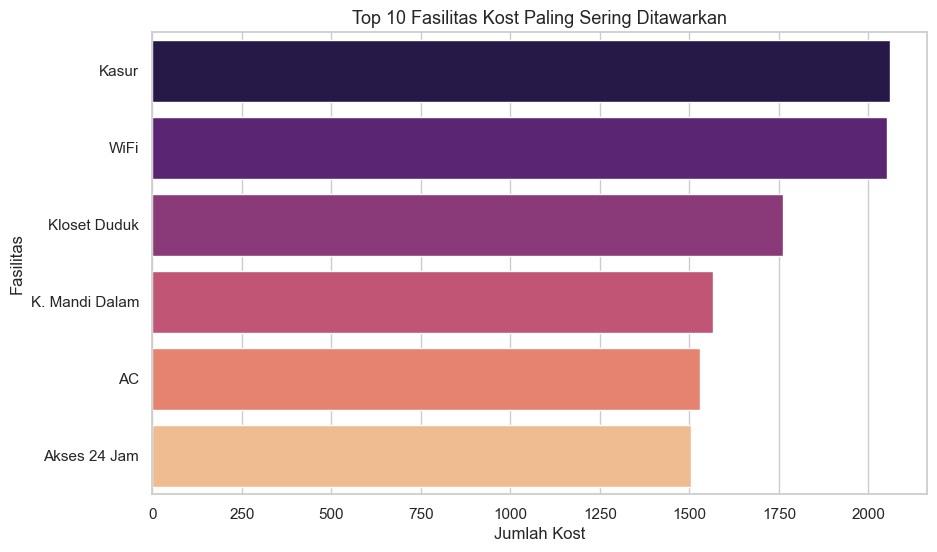

In [8]:
facilities_series = df['facilities'].dropna().str.split('·')
all_facilities = [fac.strip() for sublist in facilities_series for fac in sublist]
facilities_counts = pd.Series(all_facilities).value_counts()

sns.barplot(x=facilities_counts.values[:10], y=facilities_counts.index[:10], palette='magma')
plt.title("Top 10 Fasilitas Kost Paling Sering Ditawarkan", fontsize=13)
plt.xlabel("Jumlah Kost")
plt.ylabel("Fasilitas")
plt.show()

**Temuan:**
- Fasilitas "Kasur" dan "WiFi" hampir ada di semua kost (merupakan standar umum).
- Fasilitas seperti "AC", "Kamar Mandi Dalam", dan "Akses 24 Jam" merupakan fasilitas tambahan yang bervariasi antar kost.

Mari kita uji secara visual: Apakah kost yang menawarkan fasilitas AC dan Kamar Mandi Dalam memiliki harga sewa yang lebih tinggi secara signifikan?

---

## **Langkah 4.7: Dampak Fasilitas Premium (AC & Kamar Mandi Dalam) Terhadap Harga**
Kita akan membagi kelompok kost yang memiliki AC vs tanpa AC, serta Kamar Mandi Dalam vs tanpa Kamar Mandi Dalam, lalu membandingkan harganya melalui boxplot.

C:\Users\dzakw\AppData\Local\Temp\ipykernel_13536\3902395329.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='has_ac', y='clean_discount_price', palette='coolwarm', ax=axes[0])
C:\Users\dzakw\AppData\Local\Temp\ipykernel_13536\3902395329.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='has_kmd', y='clean_discount_price', palette='coolwarm', ax=axes[1])


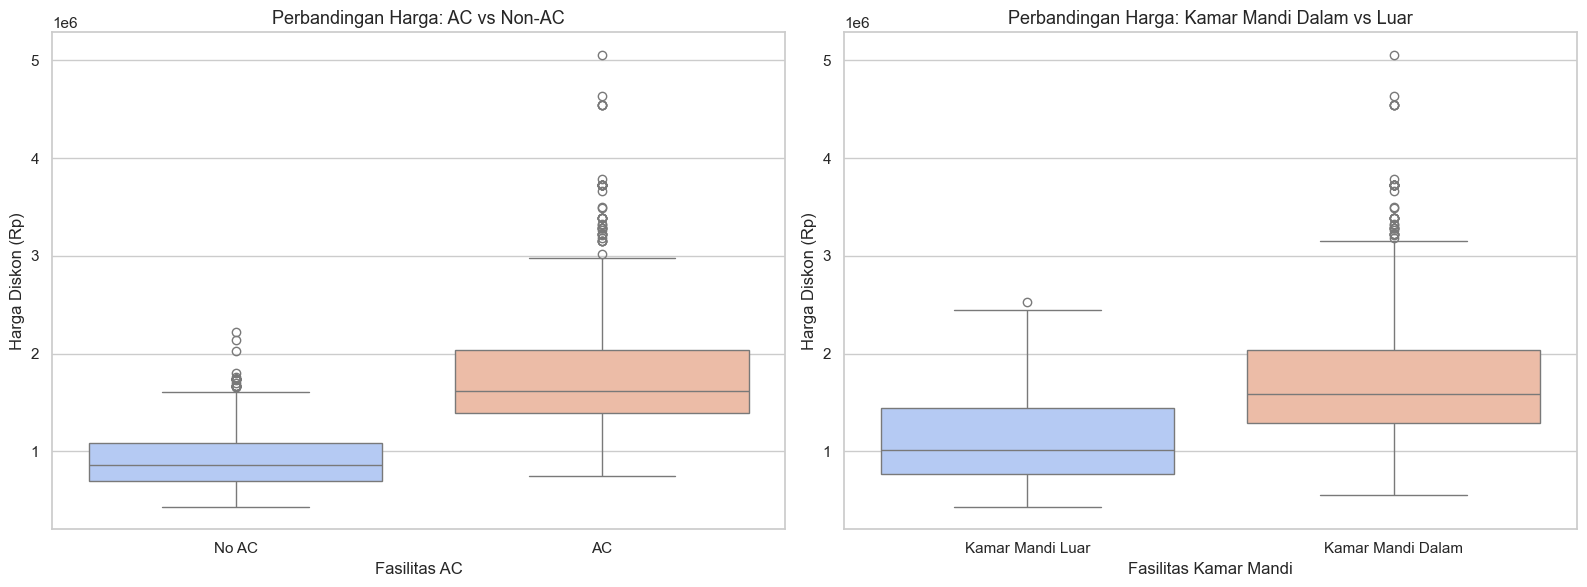

In [9]:
df['has_ac'] = df['facilities'].apply(lambda x: 'AC' if pd.notna(x) and 'AC' in str(x) else 'No AC')
df['has_kmd'] = df['facilities'].apply(lambda x: 'Kamar Mandi Dalam' if pd.notna(x) and 'K. Mandi Dalam' in str(x) else 'Kamar Mandi Luar')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot AC vs Harga
sns.boxplot(data=df, x='has_ac', y='clean_discount_price', palette='coolwarm', ax=axes[0])
axes[0].set_title("Perbandingan Harga: AC vs Non-AC", fontsize=13)
axes[0].set_xlabel("Fasilitas AC")
axes[0].set_ylabel("Harga Diskon (Rp)")

# Boxplot Kamar Mandi vs Harga
sns.boxplot(data=df, x='has_kmd', y='clean_discount_price', palette='coolwarm', ax=axes[1])
axes[1].set_title("Perbandingan Harga: Kamar Mandi Dalam vs Luar", fontsize=13)
axes[1].set_xlabel("Fasilitas Kamar Mandi")
axes[1].set_ylabel("Harga Diskon (Rp)")

plt.tight_layout()
plt.show()

**Temuan:**
- Kost yang memiliki fasilitas **AC** dan **Kamar Mandi Dalam** memiliki median harga sewa diskon yang jauh lebih tinggi secara signifikan (di atas Rp1,5 juta) dibandingkan dengan yang tidak memiliki fasilitas tersebut (di bawah Rp1 juta).
- Ini memvalidasi rencana *feature engineering* kita untuk membuat kolom biner (0/1) untuk fasilitas-fasilitas utama ini guna membantu performa prediksi model ML.

---

## **Langkah 4.8: Analisis Fitur Rating**
Terakhir, mari kita tinjau hubungan antara rating kost dengan harga diskon sewa, dan evaluasi data rating yang hilang.

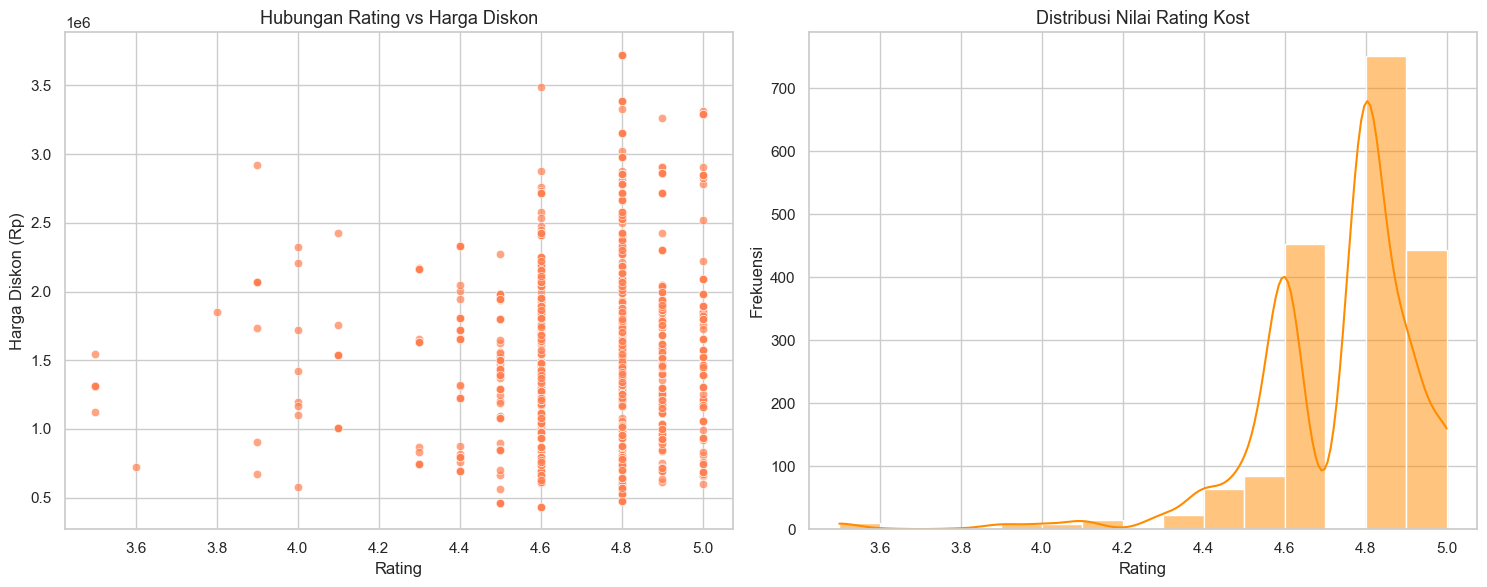

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter Plot Rating vs Harga Diskon
sns.scatterplot(data=df, x='rating', y='clean_discount_price', color='coral', alpha=0.7, ax=axes[0])
axes[0].set_title("Hubungan Rating vs Harga Diskon", fontsize=13)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Harga Diskon (Rp)")

# Plot 2: Distribusi Nilai Rating
sns.histplot(df['rating'].dropna(), bins=15, color='darkorange', kde=True, ax=axes[1])
axes[1].set_title("Distribusi Nilai Rating Kost", fontsize=13)
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

**Temuan:**
- Nilai rating menumpuk sangat tinggi di kisaran 4.5 hingga 5.0 (positif miring / *left-skewed*).
- Tidak ada korelasi linier yang kuat antara rating dan harga (kost dengan rating 5.0 bisa berharga murah maupun mahal).
- Karena distribusi rating sangat condong ke arah nilai tinggi, strategi terbaik untuk mengimputasi **202 missing values** pada kolom rating adalah menggunakan **median** (yaitu 4.8) agar nilai imputasi tidak bergeser terlalu jauh dari kenyataan.

# **5. Data Preprocessing & Pipeline Pemrosesan Akhir**

Berdasarkan seluruh hasil temuan analisis eksploratif di atas, kita menyusun langkah preprocessing sebagai berikut:
1. **Penghapusan Duplikat**: Untuk memastikan data latih unik.
2. **Imputasi Missing Values**:
   - Kolom `rating` diisi menggunakan median rating.
   - Kolom `clean_original_price` yang kosong diisi menggunakan `clean_discount_price` (asumsi tidak ada diskon sehingga harga asli sama dengan harga bayar).
3. **Feature Engineering**: Ekstraksi 6 fasilitas teratas menjadi fitur biner (0/1).
4. **Label Encoding**: Mengubah kolom kategorikal (`city`, `gender`, `district`) ke bentuk angka.
5. **Train-Test Split**: Memisahkan data latih (80%) dan data uji (20%).
6. **Feature Scaling**: Menggunakan `StandardScaler` untuk standarisasi kolom numerik (`rating`, `clean_original_price`).

In [11]:
# 1. Hapus duplikat
df = df.drop_duplicates().reset_index(drop=True)

# 2. Imputasi nilai kosong
df['rating'] = df['rating'].fillna(df['rating'].median())
df['clean_original_price'] = df['clean_original_price'].fillna(df['clean_discount_price'])

# 3. Ekstraksi fasilitas utama
target_facilities = ['Kasur', 'WiFi', 'Kloset Duduk', 'K. Mandi Dalam', 'AC', 'Akses 24 Jam']
for fac in target_facilities:
    df[f'fac_{fac.replace(" ", "_").replace(".", "")}'] = df['facilities'].apply(lambda x: 1 if pd.notna(x) and fac in str(x) else 0)

# 4. Label Encoding untuk variabel kategorikal
categorical_cols = ['city', 'gender', 'district']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# 5. Pemisahan Fitur (X) dan Target (y)
feature_cols = [
    'rating', 
    'clean_original_price', 
    'city_encoded', 
    'gender_encoded', 
    'district_encoded'
] + [f'fac_{fac.replace(" ", "_").replace(".", "")}' for fac in target_facilities]

X = df[feature_cols]
y = df['clean_discount_price']

# 6. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Standarisasi Fitur Numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Pipeline Selesai:")
print("Dimensi X_train_scaled :", X_train_scaled.shape)
print("Dimensi y_train        :", y_train.shape)

Preprocessing Pipeline Selesai:
Dimensi X_train_scaled : (1168, 11)
Dimensi y_train        : (1168,)


# **6. Menyimpan Dataset Hasil Preprocessing**
Dataset akhir yang telah dibersihkan akan disimpan untuk digunakan pada tahap pemodelan Machine Learning.

In [12]:
preprocessed_df = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
preprocessed_df.to_csv("mamikos_preprocessing_dataset.csv", index=False)
print("Preprocessed dataset saved successfully to 'mamikos_preprocessing_dataset.csv'!")

Preprocessed dataset saved successfully to 'mamikos_preprocessing_dataset.csv'!
